# Multiple Linear Regression
Multiple features (X1..Xn) -> one continuous output (y).
We evaluate with R^2, MSE, RMSE and interpret the coefficients.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## 1. Load data (Diabetes dataset: 10 features -> disease progression score)

In [3]:
data = load_diabetes(as_frame=True)
X, y = data.data, data.target
print(X.shape)
X.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Train the model  (y = b0 + b1*x1 + ... + bn*xn)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept (b0):", round(model.intercept_, 3))
coef_df = pd.DataFrame({"feature": X.columns, "coefficient": model.coef_}).sort_values("coefficient")
print(coef_df.to_string(index=False))

Intercept (b0): 151.346
feature  coefficient
     s1  -931.488846
    sex  -241.964362
    age    37.904021
     s6    48.670657
     s3   163.419983
     s4   275.317902
     bp   347.703844
     s2   518.062277
    bmi   542.428759
     s5   736.198859


## 3. Evaluate: R^2, Adjusted R^2, MSE, RMSE, MAE

In [6]:
y_pred = model.predict(X_test)
n, p = X_test.shape
r2 = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
mse = mean_squared_error(y_test, y_pred)

print(f"R^2          : {r2:.4f}")
print(f"Adjusted R^2 : {adj_r2:.4f}")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {np.sqrt(mse):.2f}")
print(f"MAE          : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Train R^2    : {model.score(X_train, y_train):.4f}  (compare with test R^2 to detect overfitting)")

R^2          : 0.4526
Adjusted R^2 : 0.3824
MSE          : 2900.19
RMSE         : 53.85
MAE          : 42.79
Train R^2    : 0.5279  (compare with test R^2 to detect overfitting)


## 4. Predict output for a new sample

In [7]:
new_sample = X_test.iloc[[0]]
print("Predicted:", model.predict(new_sample)[0].round(2), "| Actual:", y_test.iloc[0])

Predicted: 139.55 | Actual: 219.0


## 5. Which feature matters most? Compare coefficients on standardized features
Raw coefficients are not comparable when features have different scales.

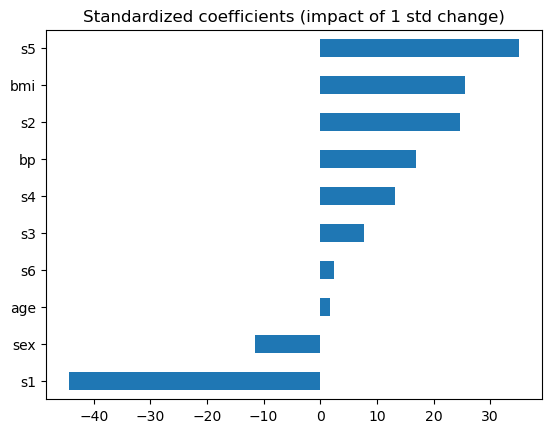

In [8]:
scaler = StandardScaler().fit(X_train)
m_std = LinearRegression().fit(scaler.transform(X_train), y_train)
std_coef = pd.Series(m_std.coef_, index=X.columns).sort_values()
std_coef.plot(kind="barh", title="Standardized coefficients (impact of 1 std change)")
plt.show()

## 6. Diagnostics: predicted vs actual, residuals

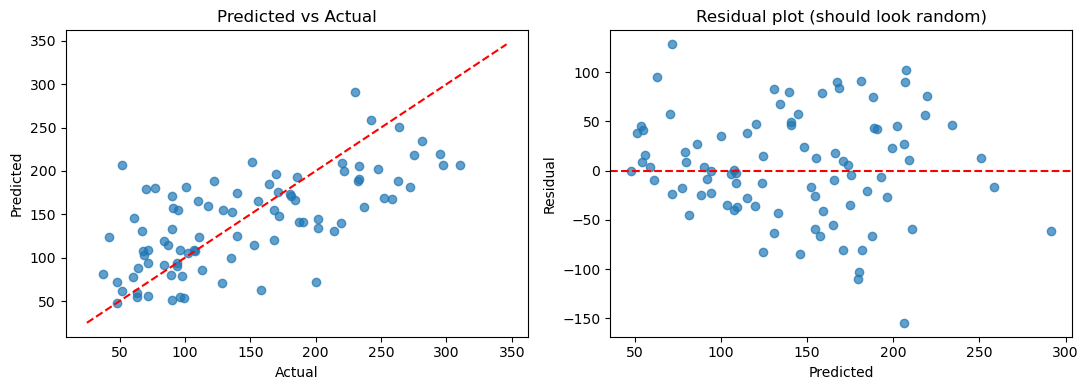

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(y_test, y_pred, alpha=0.7)
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--")
ax[0].set(xlabel="Actual", ylabel="Predicted", title="Predicted vs Actual")
residuals = y_test - y_pred
ax[1].scatter(y_pred, residuals, alpha=0.7)
ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="Predicted", ylabel="Residual", title="Residual plot (should look random)")
plt.tight_layout()
plt.show()

## 7. Multicollinearity check (correlation between features)

In [10]:
corr = X.corr()
print(corr.abs().where(~np.eye(len(corr), dtype=bool)).max().sort_values(ascending=False).head(4))

s1    0.896663
s2    0.896663
s3    0.738493
s4    0.738493
dtype: float64
